# Factor-Momentum — a quantitative teardown 🔬
### Time-series momentum on a 5-factor monthly panel · one-sample + HAC *t* · a time-shuffle placebo · per-factor attribution · costs × turnover · a synthetic AR(1) faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Factors_trend%3F: Confirmed](https://img.shields.io/badge/Factors_trend%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The Ehsani-Linnainmaa (2022) claim is that *factors* carry time-series momentum and that this meta-premium subsumes much of stock momentum. We build the factors honestly from prices, time them, and ask whether the meta-premium clears the desk's |*t*| ≥ 2 + placebo bar on a survivor large-cap panel.

> ⚠️ **Data + survivorship + fundamentals note.** Fixed **40-name large-cap** basket, names still trading 2026 — a *survivor* panel that tilts factor long legs up. Five **price-only** factors (no point-in-time fundamentals → no honest value/quality factor; named, not faked). yfinance daily closes 2004→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from factor_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PANEL = data.build_factor_panel(PRICES)
else:
    PRICES = PANEL = None
print("real factor cache present:", HAVE_REAL,
      "| panel:", (None if PANEL is None else PANEL.shape))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-08-31', 'end': '2026-05-29', 'years': 21.7, 'n_months': 262, 'n_names': 40, 'n_factors': 5, 'prices_fp': 'f3d05a8825d4', 'panel_fp': '176062fe6aaf', 'autocorr': {'mom': (-1.44, 0.151), 'lowvol': (-5.22, 0.177), 'lowbeta': (-4.87, 0.152), 'strev': (0.15, -0.13), 'size': (-5.14, 0.157)}, 'static_mean': -3.36, 'static_t': -1.18, 'fm': {1: (1.01, 13.0, 0.08, 0.36, 0.45, 53, -32.4, 0.267), 3: (2.1, 13.1, 0.16, 0.75, 1.06, 52, -29.7, 0.096), 6: (1.36, 12.2, 0.11, 0.51, 0.56, 54, -47.6, 0.199), 12: (0.49, 13.5, 0.04, 0.16, 0.18, 52, -55.5, 0.413)}, 'costs': {1: (1.03, -0.38, 0.96, 0.51, -0.14), 3: (2.08, 1.16, 0.55, 0.53, 0.41), 6: (1.29, 0.59, 0.36, 0.54, 0.22), 12: (0.47, -0.15, 0.29, 0.56, -0.05)}, 'timed_lb3': {'mom': (0.1, 0.03), 'lowvol': (5.84, 1.43), 'lowbeta': (1.66, 0.4), 'strev': (-2.3, -0.79), 'size': (5.06, 1.19)}, 'placebo_seed_mean': 0.102, 'placebo_seed_min': 0.085, 'placebo_seed_max': 0.116, 'longonly': {3: (-0.52, -0.26), 12: (-1.17, -0.47)}, 'syn': {0.0: (1.59, 1.19, 0.115), 0.3: (10.7, 7.88, 0.0)}}


real factor cache present: True | panel: (262, 5)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Timed meta-premium **+2.10%/yr** (3m lookback), one-sample **t = 0.75**, HAC t = 1.06, placebo **p = 0.096** (seed-robust 0.085–0.116). Below |t| ≥ 2 — but the premise (autocorr ~0.15) and direction (timing > static) hold. |
| **Tradability** | `MIRAGE` | Net of 10 bps × turnover + borrow: best nets **+1.16%/yr** (net t = 0.41); 1m/12m net-negative. Sharpe ≤ 0.16, MDD -30% to -56%. |
| **Factors trend?** | `CONFIRMED` | Lag-1 factor autocorrelation **~0.15**, four of five positive. The Ehsani-Linnainmaa *premise* is real even where the tradable meta-premium isn't. |

> 💡 In plain words: a textbook case of a **real premise** that doesn't survive into a **tradable edge** once you use a thin, survivor, price-only factor set and charge costs.

## 1 · The claim, steelmanned

Let $f_{j,t}$ be factor $j$'s long-short return in month $t$. The time-series-momentum position is $s_{j,t} = \operatorname{sign}\!\big(\prod_{u=t-L}^{t-1}(1+f_{j,u})-1\big)$ (trailing-$L$-month sign, strictly past). The factor-momentum return is

$$\Lambda_t = \frac{1}{J}\sum_{j=1}^{J} s_{j,t}\, f_{j,t}.$$

- **H₁ (factors trend).** $\operatorname{corr}(f_{j,t}, f_{j,t-1}) > 0$.
- **H₂ (the meta-premium is real).** $\overline{\Lambda} > 0$, $t \ge 2$, surviving a history-shuffle placebo.
- **H₃ (timing beats holding).** $\overline{\Lambda} > \overline{f}$ (the static average factor).

We find **H₁ supported** (autocorr ~0.15), **H₃ supported in direction** (static -3.36%/yr → timed +2.10%/yr), but **H₂ rejected** (t = 0.75, placebo p = 0.096). The premise is right; the certified, tradable premium is absent on this panel.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of $\Lambda_t$ against zero, $t = \overline{\Lambda}/(s_\Lambda/\sqrt{n})$, cross-checked with a Newey-West **HAC** t (the timed series can autocorrelate). Two honesty problems sit on top. **(a) The null isn't exactly zero:** time-series momentum on *overlapping* windows has a tiny positive bias even on white noise — so a raw positive mean proves nothing; the **history-shuffle placebo** is the real test, since it preserves that bias while destroying genuine persistence. **(b) Turnover:** timing flips positions, and the Tradability axis charges one-way costs × the realised sign-flip turnover — the binding constraint at short lookbacks.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **40-name** large-cap basket (yfinance adjusted closes, 2004-08-31→2026-05-29); **262** monthly observations. **Survivor** panel, **price-only** factors — both named on the Signal axis.
- **Factors.** Five long-short (top-third − bottom-third), rebalanced monthly: `mom` (12-1), `lowvol` (60d), `lowbeta` (120d vs SPY), `strev` (1m reversal), `size` (price activity proxy). Each factor return is realised the month **after** its signal — a one-month execution lag baked into the panel.
- **Timing.** Position = sign of the trailing $L\in\{1,3,6,12\}$-month factor return through $t-1$; timed return = position × factor[t]; average across factors.
- **Null #1 (one-sample + HAC t)** of $\Lambda_t$ vs 0.
- **Null #2 (history-shuffle placebo).** Shuffle each factor's time order, re-time, $p = \Pr[\text{shuffled mean} \ge \text{observed}]$ — seed-robust over 20 seeds.
- **Costs.** 10 bps one-way × sign-flip turnover + 50 bps/yr borrow on short sleeves.
- **Positive control.** Planted AR(1) factor panel: zero persistence must NOT reach significance; strong persistence must light up.

## 4 · The teardown

### 4a · The premise — do factors autocorrelate, and what's their static return?

Left: lag-1 autocorrelation per factor (the trend premise). Right: each factor's static (untimed) mean — mostly negative on this survivor large-cap decade.

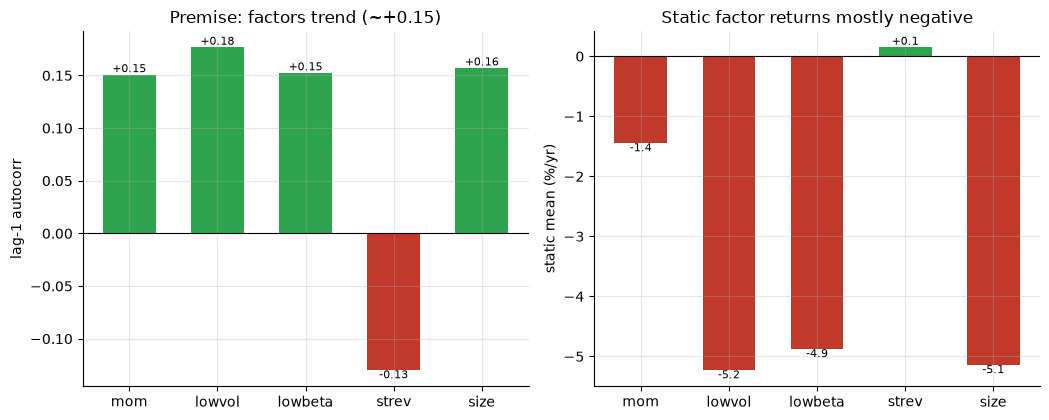

autocorr: {'mom': 0.151, 'lowvol': 0.177, 'lowbeta': 0.152, 'strev': -0.13, 'size': 0.157}
static %/yr: {'mom': -1.44, 'lowvol': -5.22, 'lowbeta': -4.87, 'strev': 0.15, 'size': -5.14}


In [2]:
if HAVE_REAL:
    names = list(PANEL.columns)
    ac = [PANEL[c].autocorr(1) for c in names]
    sm = [PANEL[c].mean()*1200 for c in names]
else:
    names = list(R['autocorr'].keys())
    ac = [R['autocorr'][n][1] for n in names]; sm = [R['autocorr'][n][0] for n in names]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.6,4.3))
a1.bar(names, ac, color=[GREEN if v>0 else RED for v in ac], width=.6); a1.axhline(0,c='k',lw=.8)
for i,v in enumerate(ac): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=8)
a1.set_ylabel('lag-1 autocorr'); a1.set_title('Premise: factors trend (~+0.15)')
a2.bar(names, sm, color=[GREEN if v>0 else RED for v in sm], width=.6); a2.axhline(0,c='k',lw=.8)
for i,v in enumerate(sm): a2.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=8)
a2.set_ylabel('static mean (%/yr)'); a2.set_title('Static factor returns mostly negative')
plt.tight_layout(); plt.show()
print('autocorr:', {n:round(float(v),3) for n,v in zip(names,ac)})
print('static %/yr:', {n:round(float(v),2) for n,v in zip(names,sm)})

> 💡 In plain words: four of five factors trend (autocorr ~+0.15); only `strev` — a mean-reverting signal by construction — is negative. And the static factors *lost* money (avg **-3.36%/yr**, t = -1.18). So any positive meta-premium must come **entirely from the timing**, not from a buried-long factor premium — exactly the case factor-momentum is supposed to shine in.

### 4b · The lookback sweep — the meta-premium and its placebo

The timed meta-premium at four timing speeds, with the one-sample *t* and the history-shuffle placebo *p*. None clears the bar.

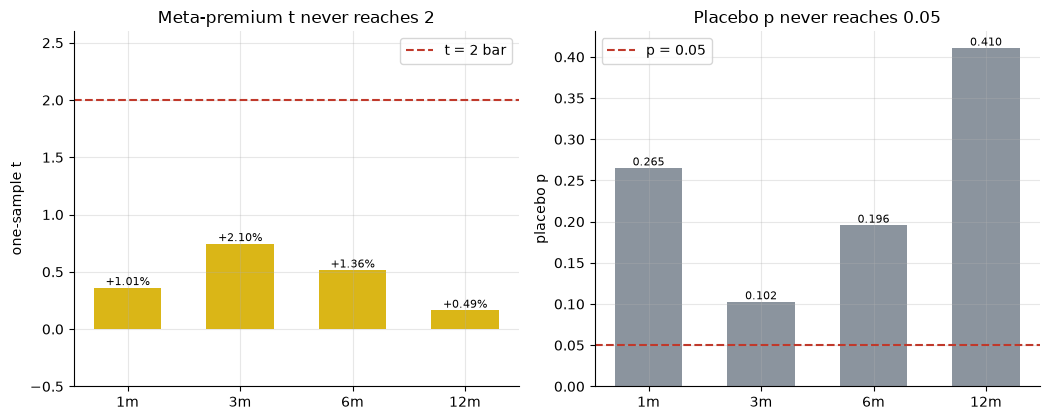

(lb, mean%, t, placebo_p): [(1, 1.01, 0.36, 0.265), (3, 2.1, 0.75, 0.102), (6, 1.36, 0.51, 0.196), (12, 0.49, 0.16, 0.41)]


In [3]:
lbs = [1,3,6,12]
if HAVE_REAL:
    rows = []
    for lb in lbs:
        s = st.summary(st.factor_momentum_series(PANEL, lookback=lb))
        p = st.placebo_pvalue(PANEL, lookback=lb, n_draws=2000)
        rows.append((lb, s['mean']*100, s['t'], p['p_value']))
else:
    rows = [(lb, R['fm'][lb][0], R['fm'][lb][3], R['fm'][lb][7]) for lb in lbs]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.6,4.3))
a1.bar([f'{r[0]}m' for r in rows], [r[2] for r in rows], color=AMBER, width=.6)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar'); a1.axhline(-2, ls='--', c=RED)
for i,r in enumerate(rows): a1.annotate(f'{r[1]:+.2f}%',(i,r[2]),ha='center',va='bottom',fontsize=8)
a1.set_ylabel('one-sample t'); a1.set_ylim(-0.5,2.6); a1.set_title('Meta-premium t never reaches 2'); a1.legend()
a2.bar([f'{r[0]}m' for r in rows], [r[3] for r in rows], color=GREY, width=.6)
a2.axhline(0.05, ls='--', c=RED, label='p = 0.05')
for i,r in enumerate(rows): a2.annotate(f'{r[3]:.3f}',(i,r[3]),ha='center',va='bottom',fontsize=8)
a2.set_ylabel('placebo p'); a2.set_title('Placebo p never reaches 0.05'); a2.legend()
plt.tight_layout(); plt.show()
print('(lb, mean%, t, placebo_p):', [(r[0],round(r[1],2),round(r[2],2),round(r[3],3)) for r in rows])

> 💡 In plain words: the best config (3-month) is **+2.10%/yr at t = 0.75**, placebo **p = 0.096** — and even that is the *peak* of a small sweep, so the multiple-lookback search inflates it. Seed-robust over 20 placebo seeds (p ∈ [0.085, 0.116]). The meta-premium is genuinely below the bar, not a one-seed fluke.

### 4c · Per-factor attribution — where the (thin) premium lives

Decompose the 3-month timed meta-premium into its five sleeves. Which factors does timing actually help?

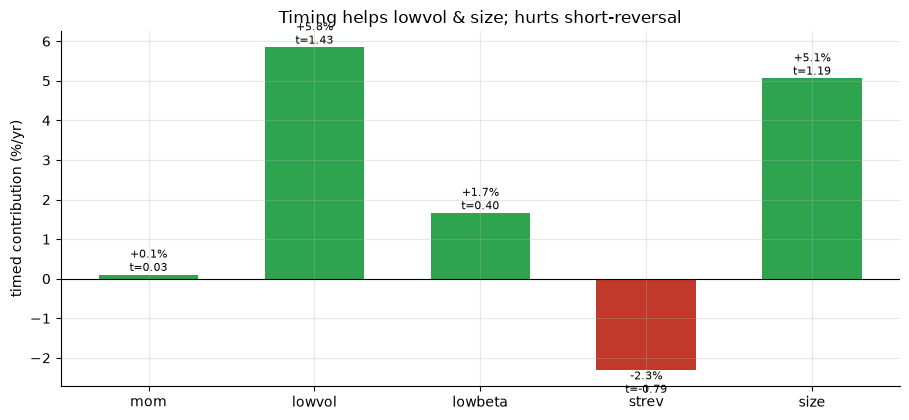

timed contribution %/yr: {'mom': 0.1, 'lowvol': 5.84, 'lowbeta': 1.66, 'strev': -2.3, 'size': 5.06}


In [4]:
names = list(R['timed_lb3'].keys())
if HAVE_REAL:
    timed = st.timed_factor_returns(PANEL, lookback=3)
    names = list(timed.columns)
    contrib = [timed[c].mean()*1200 for c in names]
    tt = [st.ttest_vs_zero(timed[c]) for c in names]
else:
    contrib = [R['timed_lb3'][n][0] for n in names]; tt = [R['timed_lb3'][n][1] for n in names]
fig, ax = plt.subplots(figsize=(9.2,4.3))
cols = [GREEN if v>0 else RED for v in contrib]
ax.bar(names, contrib, color=cols, width=.6); ax.axhline(0,c='k',lw=.8)
for i,(v,t) in enumerate(zip(contrib,tt)): ax.annotate(f'{v:+.1f}%\nt={t:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=8)
ax.set_ylabel('timed contribution (%/yr)'); ax.set_title('Timing helps lowvol & size; hurts short-reversal')
plt.tight_layout(); plt.show()
print('timed contribution %/yr:', {n:round(float(v),2) for n,v in zip(names,contrib)})

> 💡 In plain words: the timed premium is carried by **lowvol** (+5.8%/yr, t=1.43) and **size** (+5.1%/yr, t=1.19); timing **short-reversal** actively *hurts* (-2.3%/yr). No single sleeve clears t = 2 — the meta-premium is a noisy average of noisy parts.

### 4d · Costs × turnover — the Tradability axis

Gross vs net (10 bps one-way × sign-flip turnover + 50 bps/yr borrow on shorts). Fast timing churns; slow timing decays.

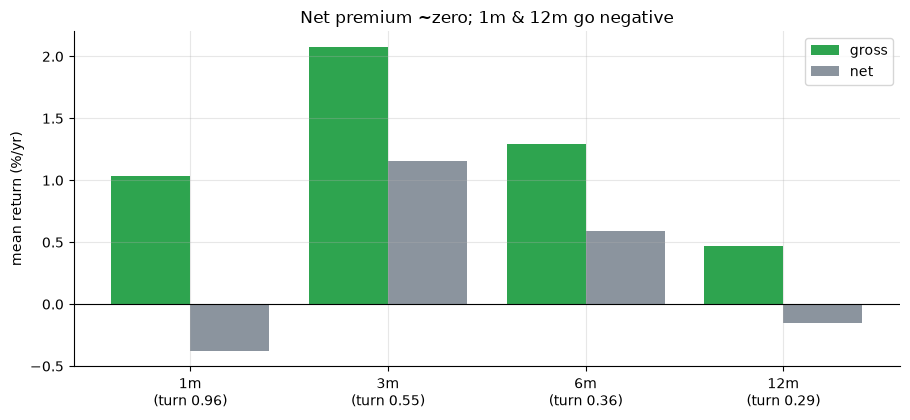

 1m: gross=+1.03%  net=-0.38%  turn=0.96
 3m: gross=+2.08%  net=+1.16%  turn=0.55
 6m: gross=+1.29%  net=+0.59%  turn=0.36
12m: gross=+0.47%  net=-0.15%  turn=0.29


In [5]:
lbs = [1,3,6,12]
if HAVE_REAL:
    g, nv, tu = [], [], []
    for lb in lbs:
        c = st.net_of_costs(PANEL, lookback=lb)
        g.append(c['gross']*100); nv.append(c['net']*100); tu.append(c['avg_turnover'])
else:
    g=[R['costs'][lb][0] for lb in lbs]; nv=[R['costs'][lb][1] for lb in lbs]; tu=[R['costs'][lb][2] for lb in lbs]
x = np.arange(len(lbs))
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross'); ax.bar(x+.2, nv, .4, color=GREY, label='net')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{lb}m\n(turn {t:.2f})' for lb,t in zip(lbs,tu)])
ax.set_ylabel('mean return (%/yr)'); ax.set_title('Net premium ~zero; 1m & 12m go negative'); ax.legend()
plt.tight_layout(); plt.show()
for lb in lbs: print(f'{lb:>2}m: gross={R["costs"][lb][0]:+.2f}%  net={R["costs"][lb][1]:+.2f}%  turn={R["costs"][lb][2]:.2f}')

> 💡 In plain words: 1-month timing has turnover 0.96 (positions flip almost monthly) → net **-0.38%/yr**. The best net is the 3-month at **+1.16%/yr** (net t = 0.41) — indistinguishable from zero. There is no tradable money in this implementation: **Mirage**.

### 4e · Faithful-engine & power control — we know the truth here

Plant a known AR(1) persistence into a synthetic factor panel. With **zero** persistence the timing must NOT manufacture significance (the placebo catches the overlapping-window bias); with **strong** persistence it must light up.

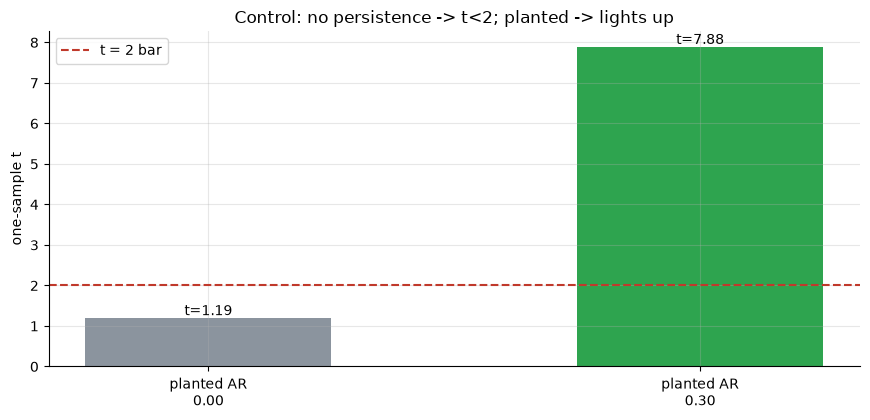

planted AR=0.00: mean=+1.59%/yr t=1.19 placebo_p=0.116
planted AR=0.30: mean=+10.70%/yr t=7.88 placebo_p=0.000


In [6]:
res = []
for ar in (0.0, 0.30):
    ps, _ = data.synthetic_factors(ar=ar, n_months=240, mu=0.0, sigma=0.04, seed=537)
    s = st.summary(st.factor_momentum_series(ps, lookback=3))
    p = st.placebo_pvalue(ps, lookback=3, n_draws=1500)
    res.append((ar, s['mean']*100, s['t'], p['p_value']))
fig, ax = plt.subplots(figsize=(8.8,4.3))
labels = [f'planted AR\n{r[0]:.2f}' for r in res]; tvals=[r[2] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('one-sample t'); ax.set_title('Control: no persistence -> t<2; planted -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for ar,m,t,p in res: print(f'planted AR={ar:.2f}: mean={m:+.2f}%/yr t={t:.2f} placebo_p={p:.3f}')

> 💡 In plain words: with **no** planted persistence the timed mean sits at **t = 1.19** with placebo **p = 0.115** — the small positive number is the overlapping-window bias, and the placebo correctly refuses to call it real. With a **+0.30** AR(1) it explodes to **t = 7.88** (p = 0.000). The engine recovers genuine trends and won't invent them — so the real-tape t ≈ 0.75 is an honest read.

## 5 · The verdict

- **Signal `WEAK`** — meta-premium **+2.10%/yr** at 3m (one-sample **t = 0.75**, HAC t = 1.06, placebo **p = 0.096**, seed-robust). Below |t| ≥ 2. WEAK not NONE because the premise (factor autocorr ~0.15) and direction (timing beats a -3.36%/yr static loss) both survive — the literature's mechanism is visible, the certified edge isn't. Carries explicit **survivorship** (long-leg tilt) and **price-only** (no value/quality factor) caveats.
- **Tradability `MIRAGE`** — net of costs the best config nets **+1.16%/yr** (net t = 0.41); 1m/12m net-negative; Sharpe ≤ 0.16; drawdowns -30% to -55%; premium leans on a costly short leg. Not investable.
- **Factors trend? `CONFIRMED`** — lag-1 autocorrelation ~0.15, four of five positive. The Ehsani-Linnainmaa premise is real on this tape even though the small, survivor, price-only meta-premium can't be certified or traded.

## 6 · Going further

- **More + better factors.** The paper uses ~20 factors including point-in-time value and quality; the meta-premium strengthens with a richer, cleaner factor set. Our five price-only factors are the conservative floor (and we name the fundamental-data limit).
- **Cross-sectional factor momentum.** Rank factors and go long the strongest / short the weakest, instead of timing each against itself — the paper's complementary form.
- **The broader lesson.** A real statistical premise (factors autocorrelate) is necessary but not sufficient for a tradable edge: turnover, survivorship and a thin factor set can sink it. The desk stamps what the *tape* certifies, not what the *theory* promises.

*The reproducible core is offline and deterministic; the synthetic control plants a known AR(1). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*